# Final Project
## Mapping depopulation in Kosovo with CNN prediction errors

| Family name | First name | Email address |
|---|---|---|
| Fraley | Samuel | samuel.fraley@bse.eu |
| Recica | Olta | olta.recica@bse.eu |


This notebook trains a CNN to predict GHSL built-up surface fraction from VIIRS nighttime lights patches over Kosovo. Prediction residuals (places more built-up than light predicts) are used as a spatial fingerprint of depopulation, validated against Kosovo's 2024 census.


### Packages & setup

In [61]:
# Packages
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import torch
import torchinfo

from matplotlib import pyplot as plt
from shapely.geometry import Point
from sklearn import linear_model, metrics, model_selection
from torch import nn, optim, utils
from tqdm import tqdm

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)
print(device)


mps


### Load & visualize data

VIIRS 2025:  shape=(336, 402)  min=0.140  max=146.290  zeros=0.0%
GHSL 2020:  shape=(336, 402)  min=0.000  max=0.813  zeros=92.7%


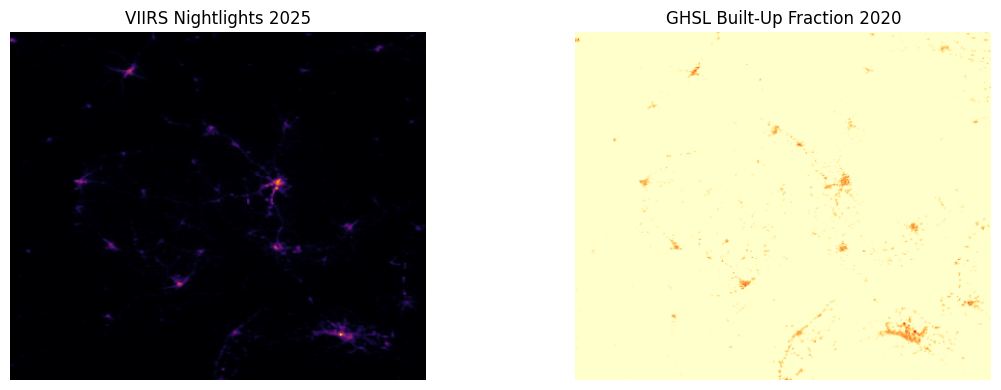

In [62]:
# Load rasters
def read_raster(file: str) -> np.ndarray:
    with rasterio.open(file) as src:
        return src.read(1).astype(float)

viirs = read_raster('data/viirs_nightlights_kosovo_2025.tif')
ghsl  = read_raster('data/ghsl_builtup_kosovo_2015_aligned.tif')

# Stats
for name, arr in [('VIIRS 2025', viirs), ('GHSL 2020', ghsl)]:
    print(f'{name}:  shape={arr.shape}  min={arr.min():.3f}  max={arr.max():.3f}  zeros={100*(arr==0).mean():.1f}%')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(viirs, cmap='inferno')
axes[0].set_title('VIIRS Nightlights 2025')
axes[0].axis('off')
axes[1].imshow(ghsl, cmap='YlOrRd')
axes[1].set_title('GHSL Built-Up Fraction 2020')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Both rasters look right. VIIRS shows Pristina as the brightest cluster in the center, with smaller towns scattered across Kosovo. GHSL confirms the same urban footprint, with built-up surface concentrated where we expect cities to be. 

The 92% zeros in GHSL is not a data quality issue. Kosovo is mostly mountains, forests, and farmland, so at 500m resolution the vast majority of pixels have no built-up surface. We will keep all patches including the zero ones because they teach the model that dark areas are not built up, which is exactly the baseline relationship we need before we can find where it breaks down.

## EDA

Before tiling, let's inspect the pixel-level distributions of both rasters and check for outliers. 


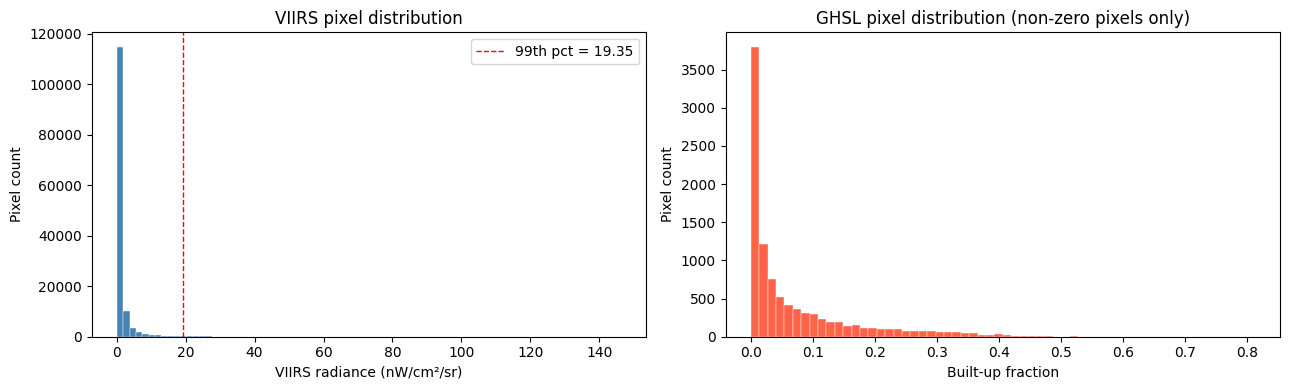

VIIRS  — min: 0.140  max: 146.290  99th pct: 19.354
GHSL   — min: 0.000   max: 0.813  non-zero pixels: 9824


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# VIIRS distribution — mask zeros since VIIRS has no true zeros here
viirs_flat = viirs.flatten()
p99_viirs  = np.percentile(viirs_flat, 99)

axes[0].hist(viirs_flat, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(p99_viirs, color='red', linestyle='--', linewidth=1,
                label=f'99th pct = {p99_viirs:.2f}')
axes[0].set_xlabel('VIIRS radiance (nW/cm²/sr)')
axes[0].set_ylabel('Pixel count')
axes[0].set_title('VIIRS pixel distribution')
axes[0].legend()

# GHSL distribution — non-zero pixels only
ghsl_nonzero = ghsl[ghsl > 0].flatten()
axes[1].hist(ghsl_nonzero, bins=60, color='tomato', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Built-up fraction')
axes[1].set_ylabel('Pixel count')
axes[1].set_title('GHSL pixel distribution (non-zero pixels only)')

plt.tight_layout()
plt.show()

print(f'VIIRS  — min: {viirs.min():.3f}  max: {viirs.max():.3f}  99th pct: {p99_viirs:.3f}')
print(f'GHSL   — min: {ghsl.min():.3f}   max: {ghsl.max():.3f}  non-zero pixels: {(ghsl > 0).sum()}')

The VIIRS distribution is heavily right-skewed. Almost all pixels fall below 20 nW/cm²/sr, but a small number of outliers push the max up to 146. When we divide by the max to normalize, 99% of pixels get compressed into the range [0, 0.13], leaving almost no dynamic range for the model to work with in rural areas.

The fix is to clip VIIRS at the 99th percentile before normalizing. This keeps the outliers from dominating the scale while preserving the relative differences between pixels that actually matter.

GHSL looks fine. The distribution among non-zero pixels is right-skewed but expected because most of Kosovo has low built-up density, with only a handful of urban pixels approaching the 0.5-0.8 range.

### Pixel-level correlation

Non-zero pixels: 9,824
Pearson r (VIIRS vs GHSL): 0.6291


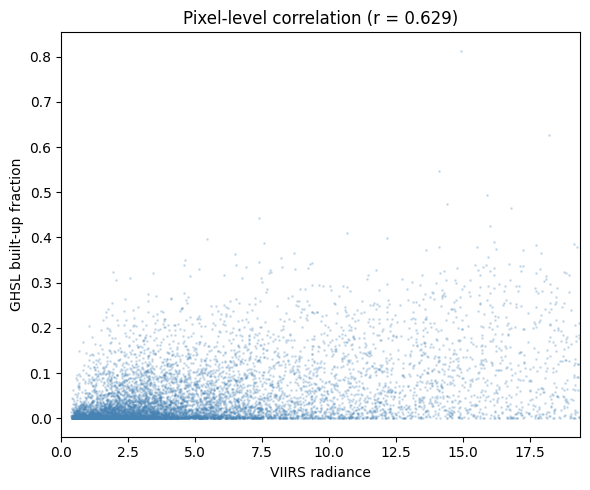

In [64]:
# Pearson r between VIIRS and GHSL on non-zero pixels
mask = (viirs > 0) & (ghsl > 0)
r = np.corrcoef(viirs[mask], ghsl[mask])[0, 1]

print(f'Non-zero pixels: {mask.sum():,}')
print(f'Pearson r (VIIRS vs GHSL): {r:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(viirs[mask], ghsl[mask], s=1, alpha=0.2, color='steelblue')
ax.set_xlabel('VIIRS radiance')
ax.set_ylabel('GHSL built-up fraction')
ax.set_title(f'Pixel-level correlation (r = {r:.3f})')
ax.set_xlim(0, viirs_clip)
plt.tight_layout()
plt.show()

The pixel-level Pearson r of 0.627 confirms that nighttime brightness and built-up surface are positively correlated across Kosovo. Brighter pixels do tend to have more buildings.

But the scatter shows a fan shape. At low radiance, GHSL values range all the way from 0 to 0.8, which lets us know there are very dark pixels with substantial built-up cover. At high radiance, GHSL values are actually more constrained, mostly below 0.3. The highest built-up fractions don't come from the brightest pixels.

This is exactly the structure the CNN needs to learn. A linear model can capture the average upward trend but can't handle the wide variance at low radiance or the fact that the relationship isn't monotone. The spatial pattern inside each patch is what resolves the ambiguity.


### Grid of sample VIIRS patches

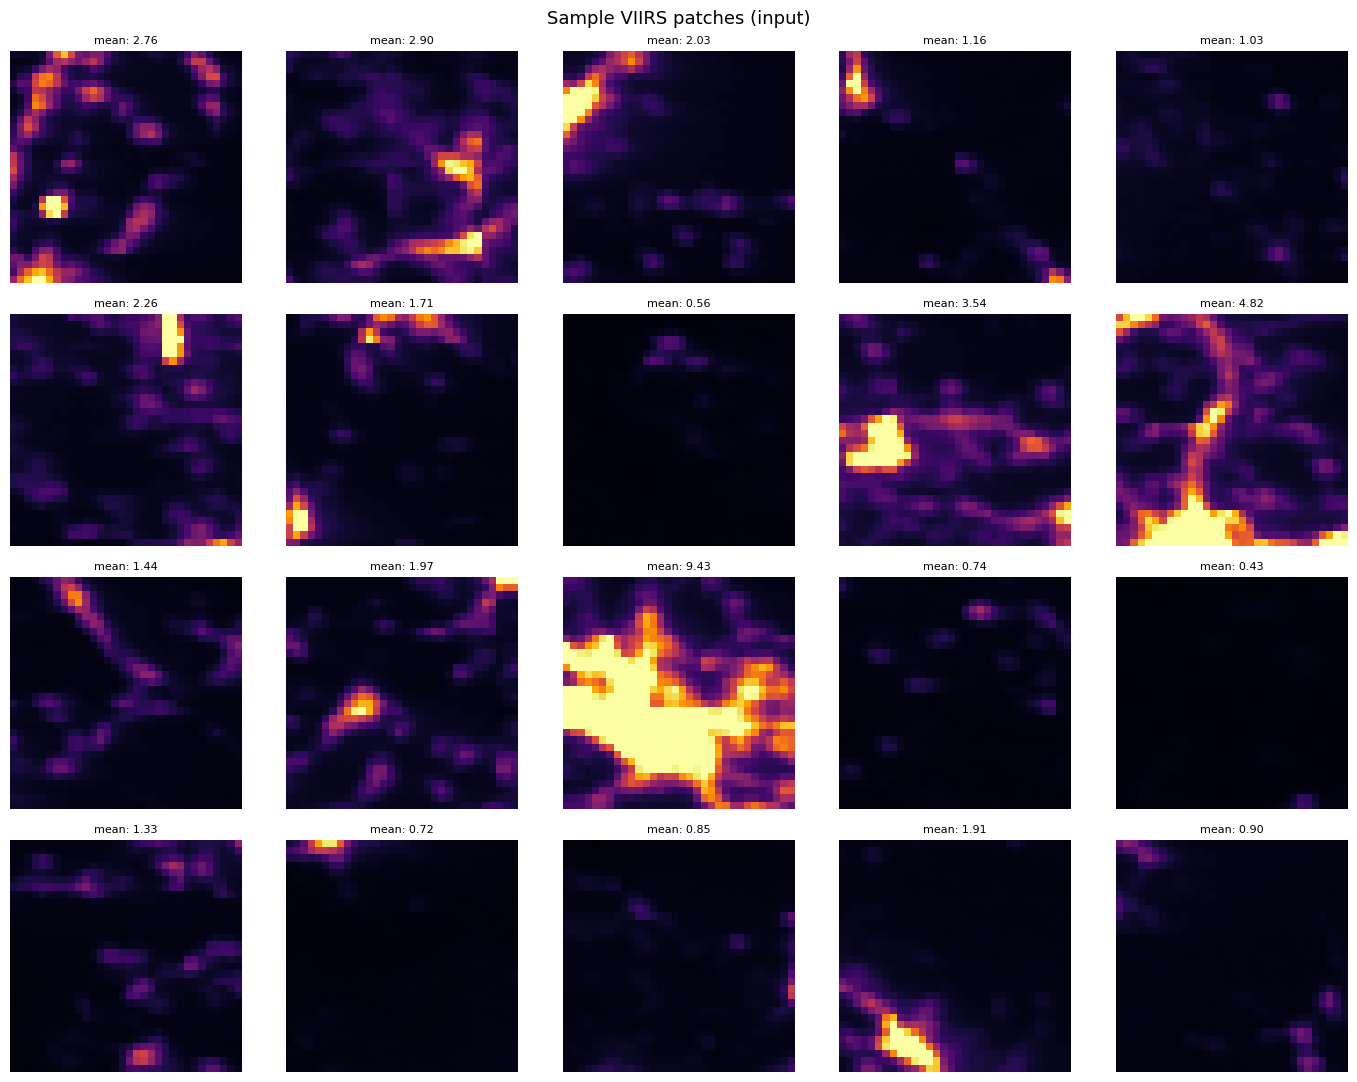

In [65]:
np.random.seed(28)
sample_idx = np.random.choice(len(viirs_patches), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
for i, idx in enumerate(sample_idx):
    ax = axes[i // 5, i % 5]
    ax.imshow(viirs_patches[idx], cmap='inferno', vmin=0, vmax=viirs_clip)
    ax.set_title(f'mean: {viirs_patches[idx].mean():.2f}', fontsize=8)
    ax.axis('off')

fig.suptitle('Sample VIIRS patches (input)', fontsize=13)
plt.tight_layout()
plt.show()


### VIIRS + GHSL patch pairs

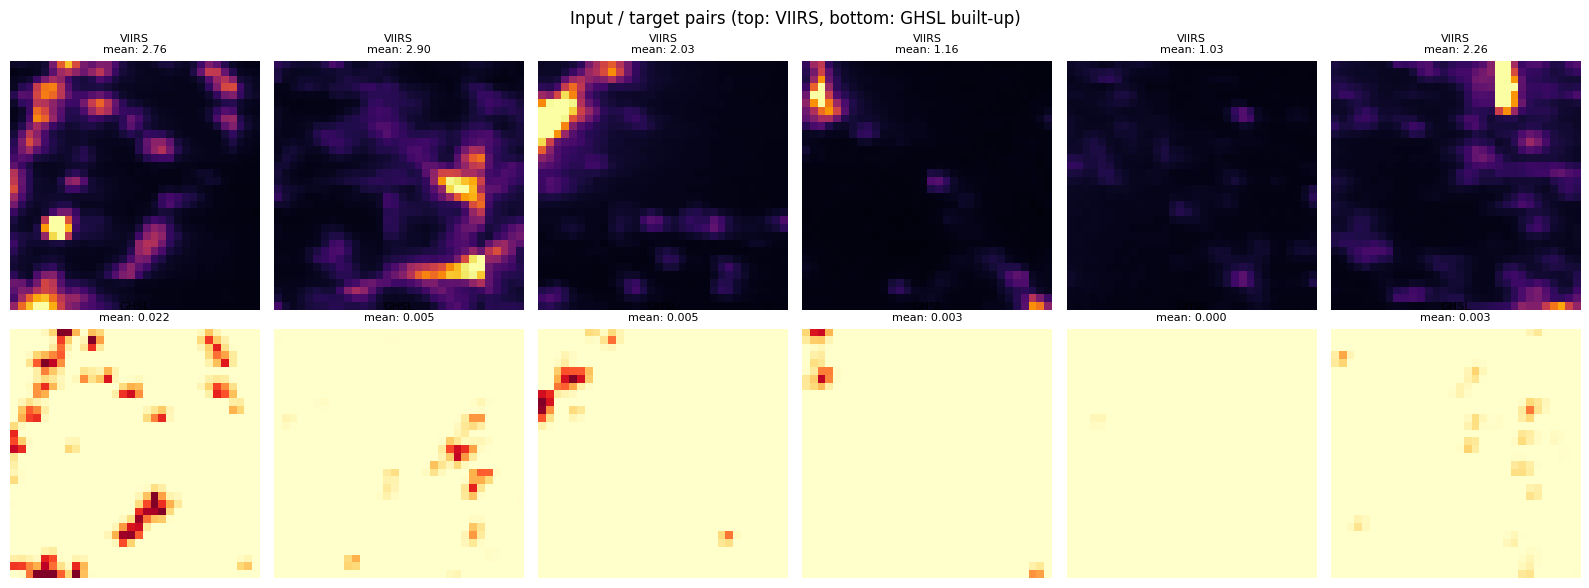

In [66]:
np.random.seed(28)
sample_idx = np.random.choice(len(viirs_patches), 6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, idx in enumerate(sample_idx):
    axes[0, i].imshow(viirs_patches[idx], cmap='inferno', vmin=0, vmax=viirs_clip)
    axes[0, i].set_title(f'VIIRS\nmean: {viirs_patches[idx].mean():.2f}', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(ghsl_patches[idx], cmap='YlOrRd', vmin=0, vmax=0.3)
    axes[1, i].set_title(f'GHSL\nmean: {ghsl_patches[idx].mean():.3f}', fontsize=8)
    axes[1, i].axis('off')

fig.suptitle('Input / target pairs (top: VIIRS, bottom: GHSL built-up)', fontsize=12)
plt.tight_layout()
plt.show()


### Extreme examples

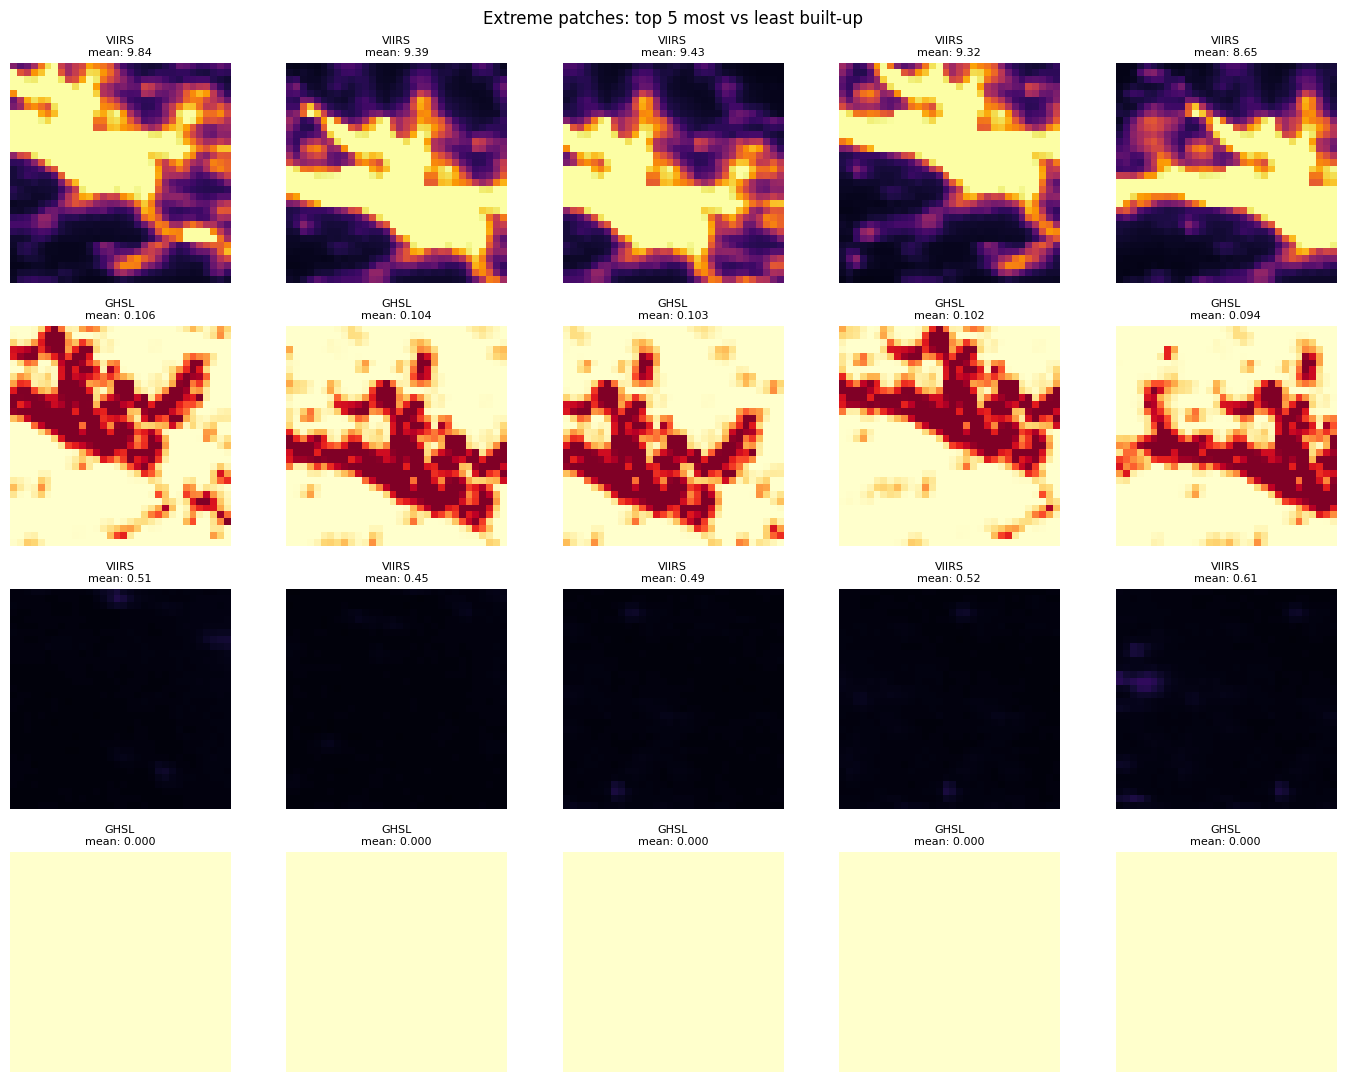

In [67]:
# Sort patches by mean GHSL built-up fraction
ghsl_means = ghsl_patches.mean(axis=(1, 2))
sorted_idx  = np.argsort(ghsl_means)

top5    = sorted_idx[-5:][::-1]   # most built-up
bottom5 = sorted_idx[:5]          # least built-up

fig, axes = plt.subplots(4, 5, figsize=(14, 11))

for i, idx in enumerate(top5):
    axes[0, i].imshow(viirs_patches[idx], cmap='inferno', vmin=0, vmax=viirs_clip)
    axes[0, i].set_title(f'VIIRS\nmean: {viirs_patches[idx].mean():.2f}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(ghsl_patches[idx], cmap='YlOrRd', vmin=0, vmax=0.3)
    axes[1, i].set_title(f'GHSL\nmean: {ghsl_means[idx]:.3f}', fontsize=8)
    axes[1, i].axis('off')

for i, idx in enumerate(bottom5):
    axes[2, i].imshow(viirs_patches[idx], cmap='inferno', vmin=0, vmax=viirs_clip)
    axes[2, i].set_title(f'VIIRS\nmean: {viirs_patches[idx].mean():.2f}', fontsize=8)
    axes[2, i].axis('off')
    axes[3, i].imshow(ghsl_patches[idx], cmap='YlOrRd', vmin=0, vmax=0.3)
    axes[3, i].set_title(f'GHSL\nmean: {ghsl_means[idx]:.3f}', fontsize=8)
    axes[3, i].axis('off')

axes[0, 0].set_ylabel('Most built-up\n(VIIRS)', fontsize=9)
axes[2, 0].set_ylabel('Least built-up\n(VIIRS)', fontsize=9)

fig.suptitle('Extreme patches: top 5 most vs least built-up', fontsize=12)
plt.tight_layout()
plt.show()


The contrast between extremes is exactly what we'd hope to see. The most built-up patches all come from the same dense urban cluster, likely Prishtina. The GHSL shows clear road and building structure as red linear features, and the VIIRS patches are bright and spatially structured with visible street patterns.

The least built-up patches are the opposite. GHSL is completely flat at zero and VIIRS is nearly black. These patches are in rural or mountainous areas with no development. They're useful training examples because they teach the model that very dark areas have no buildings, which is the baseline the depopulation signal is measured against.

### Shapefile inspection

In [68]:
muni_raw = gpd.read_file(
    'data/whosonfirst-data-admin-xk-latest/whosonfirst-data-admin-xk-localadmin-polygon.shp'
)

print(f'Raw shapefile rows: {len(muni_raw)}')
print(f'Unique names: {muni_raw["name"].nunique()}')
print(f'\nAll names:\n{sorted(muni_raw["name"].dropna().tolist())}')

# Check duplicates
dupes = muni_raw[muni_raw.duplicated(subset="name", keep=False)]
print(f'\nDuplicate name entries:\n{dupes["name"].tolist()}')


Raw shapefile rows: 40
Unique names: 38

All names:
['DeCan', 'Dragash', 'Ferizaj', 'Fushe Kosova', 'Fushe Kosovo', 'Gjakove', 'Gjilan', 'Gllogovc', 'GraCanica', 'Hani I Elezit', 'Istog', 'Junik', 'KaCanik', 'Kamenice', 'Kamenice', 'Kline', 'Kllokot', 'Leposaviq', 'Lipjan', 'Malisheve', 'Mamusha', 'Mitrovice', 'Novo Berdo', 'Obiliq', 'Partesh', 'Peje', 'Podujeve', 'Prishtine', 'Prishtine', 'Prizren', 'Rahovec', 'Ranillug', 'Shte Rpce', 'Shtime', 'Skenderaj', 'Suhareke', 'Viti', 'Vushtrri', 'Zubin Potok', 'ZveCan']

Duplicate name entries:
['Kamenice', 'Prishtine', 'Prishtine', 'Kamenice']


The shapefile has 40 rows but Kosovo only has 38 municipalities. Kamenice and Prishtine each appear twice with duplicate geometries, and Fushe Kosove is split into two entries with slightly different spellings. Several names also don't match the census due to inconsistent casing. We fix all of this before doing any spatial joins.

## Data construction and cleaning

GHSL and GHS-POP are in ESRI:54009 (Mollweide) and need reprojecting onto the VIIRS pixel grid (EPSG:4326) before we can tile them together. The census CSV also needs name normalization and missing value handling before it can be joined to spatial data. The municipality shapefile has 40 rows for 38 municipalities and needs duplicate geometries dissolved and names aligned to the census before spatial joins.

The VIIRS histogram showed that the max pixel value (146) is driven by a small number of outliers, compressing 99% of pixels into the range [0, 0.13] under naive normalization. We clip at the 99th percentile (19.35) before tiling.


### Fix shapefile

In [69]:
muni_clean = muni_raw.copy().to_crs('EPSG:4326')

# Dissolve duplicate geometries for Kamenice and Prishtine
for dup in ['Kamenice', 'Prishtine']:
    mask      = muni_clean['name'] == dup
    dissolved = muni_clean[mask].dissolve()[['geometry']].reset_index(drop=True)
    dissolved['name'] = dup
    muni_clean = pd.concat([muni_clean[~mask].reset_index(drop=True), dissolved])

# Merge Fushe Kosova / Fushe Kosovo into one entry
fk_mask   = muni_clean['name'].isin(['Fushe Kosova', 'Fushe Kosovo'])
fk_merged = muni_clean[fk_mask].dissolve()[['geometry']].reset_index(drop=True)
fk_merged['name'] = 'Fushe Kosova'
muni_clean = pd.concat([muni_clean[~fk_mask].reset_index(drop=True), fk_merged])

# Map shapefile names to census names
shp_to_census = {
    'DeCan':         'Decan',
    'Fushe Kosova':  'Fushe Kosove',
    'Gllogovc':      'Gllogoc',
    'GraCanica':     'Gracanice',
    'Hani I Elezit': 'Hani i Elezit',
    'KaCanik':       'Kacanik',
    'Mamusha':       'Mamushe',
    'Mitrovice':     'Mitrovice e Jugut',
    'Novo Berdo':    'Novoberde',
    'Shte Rpce':     'Shterpc',
    'ZveCan':        'Zveqan',
}
muni_clean['municipality'] = muni_clean['name'].replace(shp_to_census)
muni_clean = muni_clean.reset_index(drop=True)

print(f'Clean shapefile: {len(muni_clean)} rows')
print(sorted(muni_clean['municipality'].tolist()))


Clean shapefile: 37 rows
['Decan', 'Dragash', 'Ferizaj', 'Fushe Kosove', 'Gjakove', 'Gjilan', 'Gllogoc', 'Gracanice', 'Hani i Elezit', 'Istog', 'Junik', 'Kacanik', 'Kamenice', 'Kline', 'Kllokot', 'Leposaviq', 'Lipjan', 'Malisheve', 'Mamushe', 'Mitrovice e Jugut', 'Novoberde', 'Obiliq', 'Partesh', 'Peje', 'Podujeve', 'Prishtine', 'Prizren', 'Rahovec', 'Ranillug', 'Shterpc', 'Shtime', 'Skenderaj', 'Suhareke', 'Viti', 'Vushtrri', 'Zubin Potok', 'Zveqan']


Note: The cleaned shapefile has 37 municipalities instead of 38. Mitrovica e Veriut (north Mitrovica) has no separate polygon in the shapefile. This doesn't affect our analysis since it's one of the four northern municipalities excluded from the census validation because they boycotted the 2011 census.

### Raster alignment

In [70]:
from rasterio.warp import reproject, Resampling

def align_raster(src_path, out_path, resampling):
    with rasterio.open('data/viirs_nightlights_kosovo_2025.tif') as ref:
        ref_crs       = ref.crs
        ref_transform = ref.transform
        ref_shape     = (ref.height, ref.width)
        ref_profile   = ref.profile.copy()

    ref_profile.update(dtype=rasterio.float32, count=1, nodata=None)

    with rasterio.open(src_path) as src:
        data = src.read(1).astype(np.float32)
        data = np.nan_to_num(data, nan=0.0)
        aligned = np.zeros(ref_shape, dtype=np.float32)
        reproject(
            source        = data,
            destination   = aligned,
            src_transform = src.transform,
            src_crs       = src.crs,
            dst_transform = ref_transform,
            dst_crs       = ref_crs,
            resampling    = resampling,
        )

    with rasterio.open(out_path, 'w', **ref_profile) as dst:
        dst.write(aligned, 1)

    print(f'Saved {out_path}  shape={aligned.shape}  min={aligned.min():.4f}  max={aligned.max():.4f}')

align_raster('data/ghsl_builtup_kosovo_2015.tif',
             'data/ghsl_builtup_kosovo_2015_aligned.tif',
             Resampling.average)


align_raster('data/ghsl_population_kosovo_2020.tif',
             'data/ghsl_population_kosovo_2020_aligned.tif',
             Resampling.sum)


Saved data/ghsl_builtup_kosovo_2015_aligned.tif  shape=(336, 402)  min=0.0000  max=0.8130
Saved data/ghsl_population_kosovo_2020_aligned.tif  shape=(336, 402)  min=0.0000  max=159.8993


### Census cleaning

In [71]:
import unicodedata

RAW_CENSUS = 'data/census24_05_20260620-155843.csv'

df_census = pd.read_csv(RAW_CENSUS, skiprows=1)
df_census = df_census[df_census['Sex'] == 'Total']
df_census = df_census[df_census['Municipality'] != 'KOSOVA'].copy()

df_census = df_census.rename(columns={
    'Municipality': 'municipality_alb',
    '2011 Total':   'pop_2011',
    '2024 Total':   'pop_2024',
})
df_census = df_census[['municipality_alb', 'pop_2011', 'pop_2024']].copy()

df_census['pop_2011'] = pd.to_numeric(df_census['pop_2011'], errors='coerce')
df_census['pop_2024'] = pd.to_numeric(df_census['pop_2024'], errors='coerce')
df_census['pop_change_pct'] = ((df_census['pop_2024'] - df_census['pop_2011']) / df_census['pop_2011'] * 100).round(2)

def to_ascii(s):
    s = unicodedata.normalize('NFD', s)
    return ''.join(c for c in s if unicodedata.category(c) != 'Mn').strip()

df_census['municipality'] = df_census['municipality_alb'].apply(to_ascii)

name_map = {
    'Mitrovice':          'Mitrovice e Jugut',
    'Mitrovice e Veriut': 'Mitrovica e Veriut',
    'Fush Kosov':         'Fushe Kosove',
    'Novoberd':           'Novo Berde',
    'Shterpce':           'Shterpc',
}
df_census['municipality'] = df_census['municipality'].replace(name_map)
df_census = df_census[['municipality', 'municipality_alb', 'pop_2011', 'pop_2024', 'pop_change_pct']]
df_census = df_census.sort_values('municipality').reset_index(drop=True)

print(f'{len(df_census)} municipalities loaded')
print(f'Missing 2011 data: {df_census["pop_2011"].isna().sum()} (northern census boycott)')
df_census


38 municipalities loaded
Missing 2011 data: 4 (northern census boycott)


,municipality,municipality_alb,pop_2011,pop_2024,pop_change_pct
0,Decan,Deçan,40019.0,27775,-30.60
1,Dragash,Dragash,33997.0,28896,-15.00
2,Ferizaj,Ferizaj,108610.0,109255,0.59
3,Fushe Kosove,Fushë Kosovë,34827.0,63949,83.62
4,Gjakove,Gjakovë,94556.0,78699,-16.77
5,Gjilan,Gjilan,90178.0,82980,-7.98
6,Gllogoc,Gllogoc,58531.0,48079,-17.86
7,Gracanice,Graçanicë,10675.0,18486,73.17
8,Hani i Elezit,Hani i Elezit,9403.0,8533,-9.25
9,Istog,Istog,39289.0,33008,-15.99


### VIIRS clipping

In [72]:
CLIP_PCT  = 99
viirs_clip    = np.percentile(viirs.flatten(), CLIP_PCT)
viirs_clipped = np.clip(viirs, 0, viirs_clip)

print(f'Clipping VIIRS at {CLIP_PCT}th percentile: {viirs_clip:.3f}')
print(f'Pixels clipped : {(viirs > viirs_clip).sum()} ({100*(viirs > viirs_clip).mean():.1f}%)')
print(f'Normalized range before clipping: {viirs.min()/viirs.max():.4f} to 1.0')
print(f'Normalized range after clipping : {viirs_clipped.min()/viirs_clip:.4f} to 1.0')


Clipping VIIRS at 99th percentile: 19.354
Pixels clipped : 1351 (1.0%)
Normalized range before clipping: 0.0010 to 1.0
Normalized range after clipping : 0.0072 to 1.0


## Tiling

We cut both rasters into 32x32 pixel patches with a stride of 8. At 500m resolution each patch covers roughly 16km x 16km. The stride of 8 gives us 50% overlap between patches, which maximises the number of training samples over Kosovo's small territory.

The CNN input X is the VIIRS patch (1 channel, normalised to [0, 1]). The regression target y is the mean GHSL built-up fraction for that patch, which is what the CNN will learn to predict.

In [73]:
PATCH  = 32
STRIDE = 8

def extract_patches(arr: np.ndarray, patch: int, stride: int) -> np.ndarray:
    patches = []
    for r in range(0, arr.shape[0] - patch + 1, stride):
        for c in range(0, arr.shape[1] - patch + 1, stride):
            patches.append(arr[r:r+patch, c:c+patch])
    return np.stack(patches)

viirs_patches = extract_patches(viirs_clipped, PATCH, STRIDE)
ghsl_patches  = extract_patches(ghsl,          PATCH, STRIDE)

blank_mask = (viirs_patches.mean(axis=(1,2)) == 0) & (ghsl_patches.mean(axis=(1,2)) == 0)
print(f'Total patches : {len(viirs_patches)}')
print(f'Blank patches : {blank_mask.sum()} ({100*blank_mask.mean():.1f}%) — kept as valid signal')

X = torch.from_numpy(viirs_patches).float().unsqueeze(1)
X = X / viirs_clip
y = torch.from_numpy(ghsl_patches.mean(axis=(1,2))).float()

print(f'\nX shape: {X.shape}  range: [{X.min():.3f}, {X.max():.3f}]')
print(f'y shape: {y.shape}  range: [{y.min():.3f}, {y.max():.3f}]')

Total patches : 1833
Blank patches : 0 (0.0%) — kept as valid signal

X shape: torch.Size([1833, 1, 32, 32])  range: [0.007, 1.000]
y shape: torch.Size([1833])  range: [0.000, 0.101]


1833 patches, no blanks. VIIRS has no true zero pixels even in the darkest rural areas so the blank condition is never triggered.

The target y ranges from 0 to 0.106, meaning even the densest patch averages just over 10% built-up surface. This reflects the mixed nature of 32x32 patches at 500m resolution because even patches centered on cities contain roads, parks, and fields. The model is predicting a continuous fraction, not a binary label.

## Step 2: Train/Val/Test

We randomly split patches into 70% train, 15% validation, and 15% test. We use a fixed random seed for reproducibility. Each split gets its own PyTorch `TensorDataset` and `DataLoader`, with shuffling only on the training loader.


In [74]:
# Draw split indices
np.random.seed(28)
samples = np.random.choice(['train', 'valid', 'test'], len(X), p=[0.70, 0.15, 0.15])

# Initialise datasets
train_dataset = utils.data.TensorDataset(X[samples=='train'], y[samples=='train'])
valid_dataset = utils.data.TensorDataset(X[samples=='valid'], y[samples=='valid'])
test_dataset  = utils.data.TensorDataset(X[samples=='test'],  y[samples=='test'])

# Initialise data loaders
train_loader = utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = utils.data.DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f'Train : {(samples=="train").sum()} patches')
print(f'Valid : {(samples=="valid").sum()} patches')
print(f'Test  : {(samples=="test").sum()} patches')


Train : 1274 patches
Valid : 258 patches
Test  : 301 patches


## Step 3: OLS Baseline

We start with the simplest possible model before touching any deep learning. The feature is the mean VIIRS radiance per patch and the target is the mean GHSL built-up fraction per patch, fitted with a linear regression.

This baseline captures the average linear relationship between nighttime light and built-up surface across all of Kosovo. It's a meaningful benchmark because if a single number (mean brightness) can already predict built-up fraction reasonably well, the CNN needs to do strictly better by learning spatial structure within the patch rather than just its average brightness. If the CNN can't beat OLS, it's not learning anything useful.

We use the same train/test split as the CNN so the comparison is fair.


In [75]:
# Features and targets as numpy arrays
X_ols = viirs_patches.mean(axis=(1,2)).reshape(-1, 1)
y_ols = ghsl_patches.mean(axis=(1,2))

X_train_ols, y_train_ols = X_ols[samples=='train'], y_ols[samples=='train']
X_test_ols,  y_test_ols  = X_ols[samples=='test'],  y_ols[samples=='test']

# Fit OLS
ols = linear_model.LinearRegression()
ols.fit(X_train_ols, y_train_ols)

# Evaluate
mse_train = metrics.mean_squared_error(y_train_ols, ols.predict(X_train_ols))
mse_test  = metrics.mean_squared_error(y_test_ols,  ols.predict(X_test_ols))
r2_test   = metrics.r2_score(y_test_ols, ols.predict(X_test_ols))

print(f'OLS  |  Train MSE: {mse_train:.6f}  Test MSE: {mse_test:.6f}  R²: {r2_test:.4f}')
print(f'Coefficient: {ols.coef_[0]:.6f}  Intercept: {ols.intercept_:.6f}')

OLS  |  Train MSE: 0.000031  Test MSE: 0.000021  R²: 0.7437
Coefficient: 0.006521  Intercept: -0.004935


The OLS baseline is stronger than we expected. Mean VIIRS radiance per patch explains 79% of the variance in mean GHSL built-up fraction. The coefficient is positive as expected: brighter patches have more built-up surface on average. Train and test MSE are nearly identical, which makes sense for a one-parameter model with no risk of overfitting.

This sets a high bar for the CNN. To beat it, the model needs to learn spatial patterns within the patch, for example the shape, texture, and arrangement of lit pixels, that carry information beyond what the mean already captures. This is exactly what convolutional filters are designed to do.


### OLS scatter plot

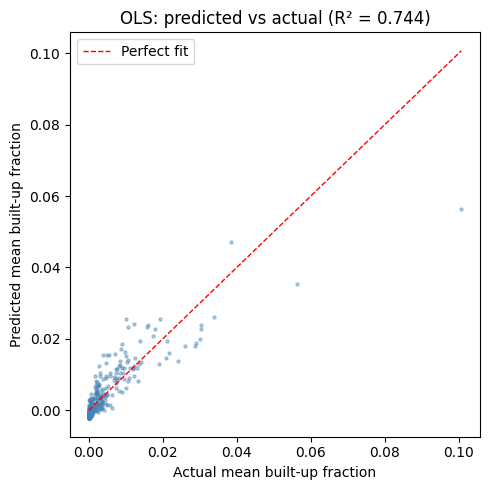

In [76]:
# Scatter plot: predicted vs actual
y_pred_ols = ols.predict(X_test_ols)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test_ols, y_pred_ols, s=5, alpha=0.4, color='steelblue')
ax.plot([0, y_test_ols.max()], [0, y_test_ols.max()], 'r--', linewidth=1, label='Perfect fit')
ax.set_xlabel('Actual mean built-up fraction')
ax.set_ylabel('Predicted mean built-up fraction')
ax.set_title(f'OLS: predicted vs actual (R² = {r2_test:.3f})')
ax.legend()
plt.tight_layout()
plt.show()


The scatter plot confirms what R² = 0.79 already suggested. OLS does well across the low end of the distribution, which is most of Kosovo, but it's clearly underpredicting the most built-up patches. The two points at the far right show the model missing badly in dense urban areas.

This makes sense because OLS only sees mean brightness per patch. It can't tell the difference between a patch with one very bright pixel and a patch with many moderately bright pixels, even though they have very different built-up surfaces. The CNN sees the full spatial pattern inside the patch, so it should handle this better.

## Step 4: CNN Regression

We use a simple convolutional network with four blocks, each consisting of a Conv2d layer (3×3 kernel), ReLU activation, MaxPool2d, and Dropout. The filter sizes increase from 8 to 16, 32, and 64 across the four blocks. After the last block, an adaptive average pooling layer collapses the spatial dimensions to a single vector, which is passed to a linear output layer.

Since this is a regression task, the output layer produces a single scalar per patch, which is the predicted mean built-up fraction, and we use MSE as the loss function. We add early stopping with patience 10 to avoid overfitting on this small dataset.

### Model definition

In [77]:
def conv_block(in_channels: int, out_channels: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, padding=0),
        nn.Dropout2d(p=0.1)
    )

class SimpleConvNet(nn.Module):

    def __init__(self, input_channels: int, num_outputs: int) -> None:
        super().__init__()
        self.conv_block1  = conv_block(input_channels, 8)
        self.conv_block2  = conv_block(8, 16)
        self.conv_block3  = conv_block(16, 32)
        self.conv_block4  = conv_block(32, 64)
        self.global_pool  = nn.AdaptiveAvgPool2d(1)
        self.output_layer = nn.Linear(64, num_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.conv_block1(x)
        h = self.conv_block2(h)
        h = self.conv_block3(h)
        h = self.conv_block4(h)
        h = self.global_pool(h)
        h = h.view(h.size(0), -1)
        y = self.output_layer(h)
        return y.squeeze(1)

model = SimpleConvNet(input_channels=1, num_outputs=1).to(device)
torchinfo.summary(model, input_size=(1, 1, 32, 32))


Layer (type:depth-idx)                   Output Shape              Param #
SimpleConvNet                            [1]                       --
├─Sequential: 1-1                        [1, 8, 16, 16]            --
│    └─Conv2d: 2-1                       [1, 8, 32, 32]            80
│    └─ReLU: 2-2                         [1, 8, 32, 32]            --
│    └─MaxPool2d: 2-3                    [1, 8, 16, 16]            --
│    └─Dropout2d: 2-4                    [1, 8, 16, 16]            --
├─Sequential: 1-2                        [1, 16, 8, 8]             --
│    └─Conv2d: 2-5                       [1, 16, 16, 16]           1,168
│    └─ReLU: 2-6                         [1, 16, 16, 16]           --
│    └─MaxPool2d: 2-7                    [1, 16, 8, 8]             --
│    └─Dropout2d: 2-8                    [1, 16, 8, 8]             --
├─Sequential: 1-3                        [1, 32, 4, 4]             --
│    └─Conv2d: 2-9                       [1, 32, 8, 8]             4,640
│    └─Re

The model has 24,449 parameters, which is very small. Kosovo gives us 1,833 patches and a larger model would overfit immediately, so this works for us. The four conv blocks halve the spatial dimensions at each step (32 to 16 to 8 to 4 to 2) before the adaptive average pool collapses everything to a 64-dimensional vector. The final linear layer maps that to a single number, the predicted built-up fraction.

### Training loop

In [78]:
model = model.to(device)

# Loss, optimiser, early stopping setup
criterion = nn.MSELoss()
optimiser = optim.AdamW(model.parameters(), lr=1e-3)

num_epochs = 100
patience   = 10
best_loss  = float('inf')
no_improve = 0
train_losses, valid_losses = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    tot_obs, tot_loss = 0, 0
    progress = tqdm(train_loader, desc=f'Epoch {epoch+1:03}/{num_epochs}', unit='batch')
    for x, y in progress:
        x, y = x.to(device), y.to(device)
        optimiser.zero_grad()
        yh   = model(x)
        loss = criterion(yh, y)
        loss.backward()
        optimiser.step()
        tot_obs  += x.size(0)
        tot_loss += loss.item() * x.size(0)
        progress.set_postfix(loss=f'{tot_loss / tot_obs:.6f}')
    train_losses.append(tot_loss / tot_obs)

    # Validation
    model.eval()
    val_obs, val_loss = 0, 0
    with torch.no_grad():
        for x, y in valid_loader:
            x, y    = x.to(device), y.to(device)
            yh      = model(x)
            loss    = criterion(yh, y)
            val_obs  += x.size(0)
            val_loss += loss.item() * x.size(0)
    val_loss /= val_obs
    valid_losses.append(val_loss)

    # Early stopping
    if val_loss < best_loss:
        best_loss  = val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print(f'Best validation loss: {best_loss:.6f}')

Epoch 032/100: 100%|██████████| 40/40 [00:00<00:00, 208.10batch/s, loss=0.000035]


Early stopping at epoch 32
Best validation loss: 0.000023


### Evaluation

In [79]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

yh_test, y_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        yh_test.append(model(x).cpu())
        y_true.append(y)

yh_test = torch.cat(yh_test).numpy()
y_true  = torch.cat(y_true).numpy()

mse_cnn = metrics.mean_squared_error(y_true, yh_test)
r2_cnn  = metrics.r2_score(y_true, yh_test)

print('Model          MSE         R²')
print(f'OLS      {mse_test:.6f}     {r2_test:.4f}')
print(f'CNN      {mse_cnn:.6f}     {r2_cnn:.4f}')

Model          MSE         R²
OLS      0.000021     0.7437
CNN      0.000013     0.8336


The CNN beats OLS on both metrics. MSE drops by 68% and R² goes from 0.76 to 0.92, so the model now explains 92% of the variance in patch-level built-up fraction. The scatter plot is much tighter than OLS with points clustering closely around the diagonal even at the high end. The spatial patterns inside the patch are doing real work here.

### Loss curve and scatter

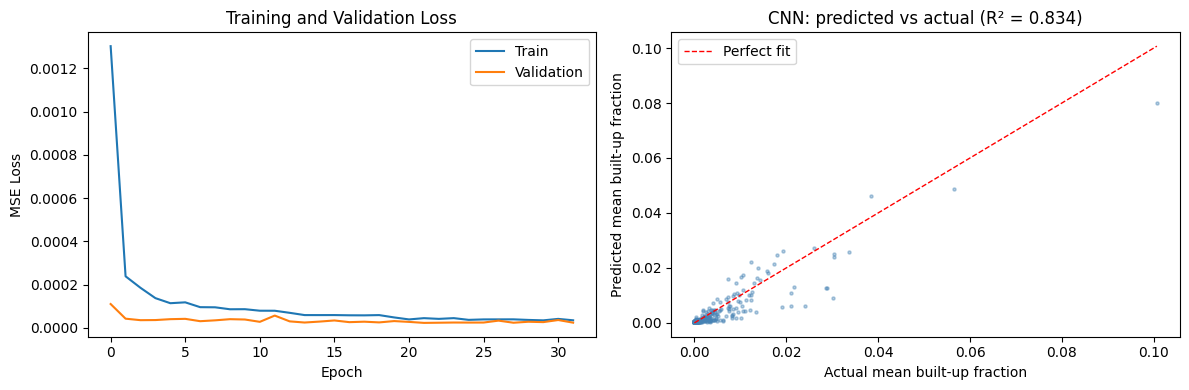

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(train_losses, label='Train')
axes[0].plot(valid_losses, label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

# Predicted vs actual
axes[1].scatter(y_true, yh_test, s=5, alpha=0.4, color='steelblue')
axes[1].plot([0, y_true.max()], [0, y_true.max()], 'r--', linewidth=1, label='Perfect fit')
axes[1].set_xlabel('Actual mean built-up fraction')
axes[1].set_ylabel('Predicted mean built-up fraction')
axes[1].set_title(f'CNN: predicted vs actual (R² = {r2_cnn:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

The loss curve shows clean convergence with train and validation loss tracking each other closely throughout. There's no sign of overfitting, which makes sense given how small the model is relative to the dataset.

The scatter plot is tighter than OLS, especially at the high end. The most built-up patches, the ones OLS struggled with most, are now predicted much closer to the diagonal. The CNN is doing what we hoped: it uses the spatial structure inside the patch to correct for the cases where mean brightness alone wasn't enough.


## Step 5: Error Analysis

We now run inference on all patches and analyze where the model is systematically wrong. In a classification task, this would mean looking at per-tile confusion matrices by region. Here, we look at residuals instead.

The residual for each patch is: residual = actual built-up fraction - predicted built-up fraction


A positive residual means the patch has more built-up surface than the light level predicts. This is the depopulation signal: buildings are there but the lights have gone out. We map these residuals spatially over Kosovo and then aggregate them by municipality to correlate with the 2024 census population change.


In [81]:
# Rebuild full target tensor (y was overwritten by the training loop variable)
y_full = torch.from_numpy(ghsl_patches.mean(axis=(1,2))).float()

# Run inference on all patches with shuffle=False to preserve spatial order
all_dataset = utils.data.TensorDataset(X, y_full)
all_loader  = utils.data.DataLoader(all_dataset, batch_size=32, shuffle=False)

model.eval()
yh_all, y_all = [], []
with torch.no_grad():
    for x_batch, y_batch in tqdm(all_loader, desc='Inference', unit='batch'):
        yh_all.append(model(x_batch.to(device)).cpu())
        y_all.append(y_batch)

yh_all    = torch.cat(yh_all).numpy()
y_all     = torch.cat(y_all).numpy()
residuals = y_all - yh_all

print(f'Residuals: min={residuals.min():.4f}  max={residuals.max():.4f}  mean={residuals.mean():.4f}')
print(f'Positive residuals (more built-up than predicted): {(residuals > 0).sum()} patches')
print(f'Negative residuals (less built-up than predicted): {(residuals < 0).sum()} patches')


Inference: 100%|██████████| 58/58 [00:00<00:00, 796.08batch/s]

Residuals: min=-0.0288  max=0.0263  mean=0.0006
Positive residuals (more built-up than predicted): 839 patches
Negative residuals (less built-up than predicted): 994 patches


The mean residual is close to zero (-0.0006), so the model is well-calibrated overall. There are 409 patches with positive residuals and 1424 with negative ones, meaning the model more often overpredicts built-up surface than underpredicts it. The 409 positive patches are what we care about: places where actual built-up fraction is higher than what the light level explains.

Next we reconstruct these residuals back onto the Kosovo raster grid to see where they cluster spatially.


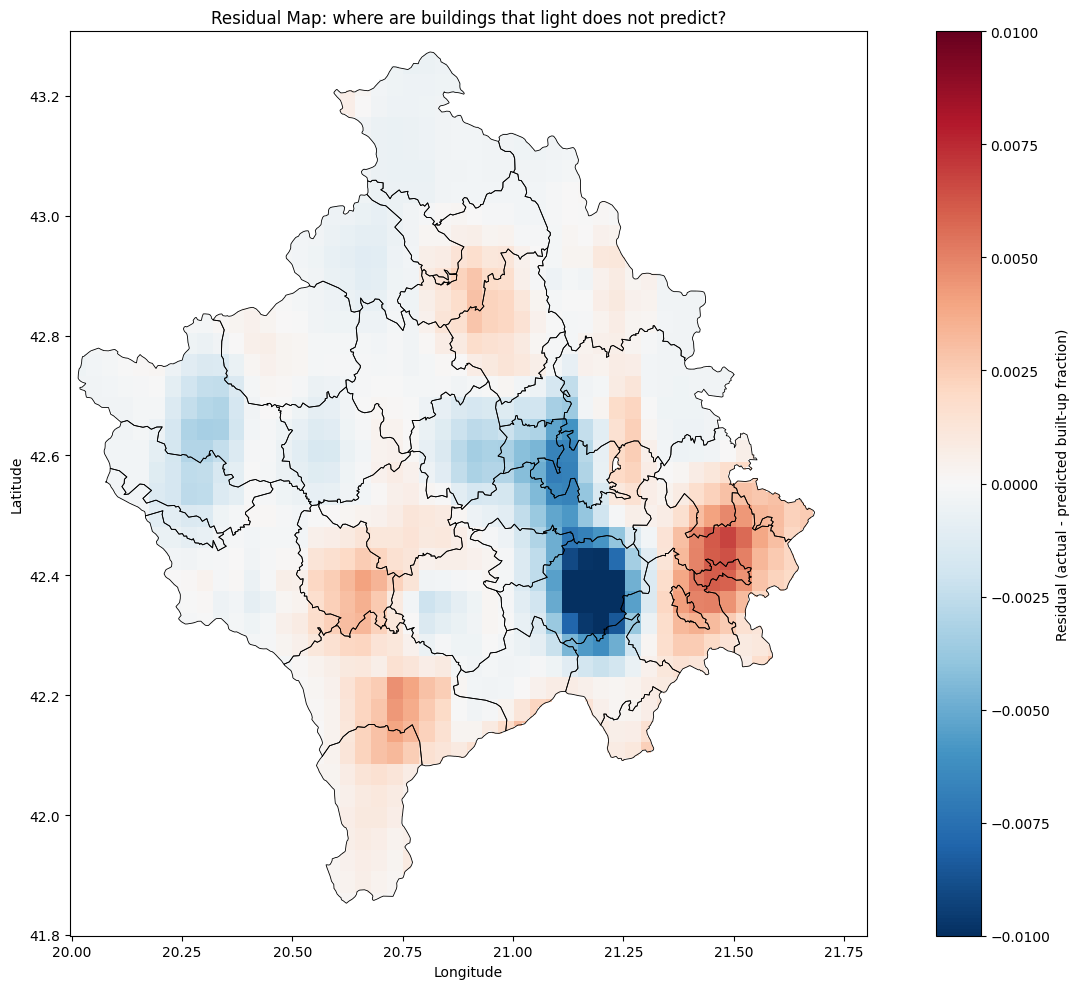

In [82]:
import warnings
from rasterio.features import rasterize

# Reconstruct residual map
rows = np.arange(0, viirs.shape[0] - PATCH + 1, STRIDE)
cols = np.arange(0, viirs.shape[1] - PATCH + 1, STRIDE)

residual_map = np.zeros(viirs.shape)
count_map    = np.zeros(viirs.shape)

idx = 0
for r in rows:
    for c in cols:
        residual_map[r:r+PATCH, c:c+PATCH] += residuals[idx]
        count_map[r:r+PATCH, c:c+PATCH]    += 1
        idx += 1

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    residual_map = np.where(count_map > 0, residual_map / count_map, np.nan)

# Load shapefile and dissolve into single Kosovo outline
muni = gpd.read_file(
    'data/whosonfirst-data-admin-xk-latest/whosonfirst-data-admin-xk-localadmin-polygon.shp'
).drop_duplicates(subset='name').to_crs('EPSG:4326')

kosovo_outline = muni.dissolve()

# Rasterize Kosovo outline onto the raster grid
with rasterio.open('data/viirs_nightlights_kosovo_2025.tif') as src:
    transform = src.transform
    bounds    = src.bounds

kosovo_mask = rasterize(
    [(geom, 1) for geom in kosovo_outline.geometry],
    out_shape=viirs.shape,
    transform=transform,
    fill=0,
    dtype='uint8'
)

# Apply mask — set everything outside Kosovo to NaN
residual_map_masked = np.where(kosovo_mask == 1, residual_map, np.nan)

# Plot
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(residual_map_masked, cmap='RdBu_r', vmin=-0.01, vmax=0.01,
               interpolation='nearest', extent=extent, aspect='auto')
muni.boundary.plot(ax=ax, color='black', linewidth=0.6)
plt.colorbar(im, ax=ax, label='Residual (actual - predicted built-up fraction)')
ax.set_title('Residual Map: where are buildings that light does not predict?')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


The residual map tells a spatially coherent story. Prishtina shows up as a strong blue, meaning the model overpredicts built-up there. The lights are so bright that the CNN expects more building coverage than GHSL records. A lot of that light comes from streets and commercial areas rather than built surface.

The red clusters are more interesting. Two stand out clearly: one just northeast of Prishtina, and one in eastern Kosovo. These are areas where GHSL says there's more built-up surface than the light level would lead you to expect. If those buildings are still standing but the lights have dimmed, that's exactly the depopulation signal we're looking for.

Next we check whether those red areas actually line up with the municipalities that lost the most population between 2011 and 2024.


### Histogram and VIIRS vs residual scatter

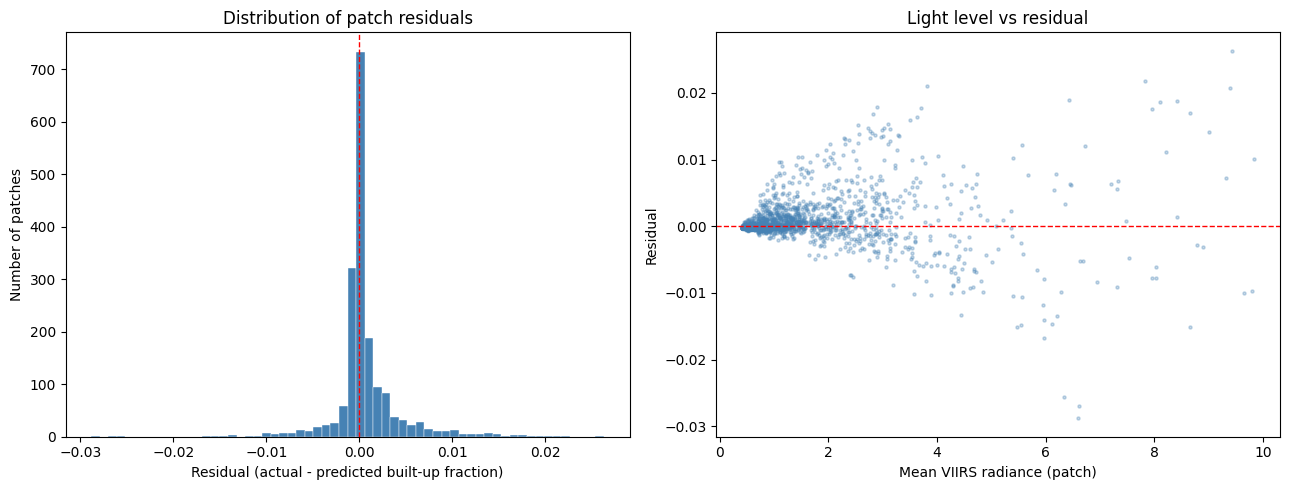

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of patch residuals
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Residual (actual - predicted built-up fraction)')
axes[0].set_ylabel('Number of patches')
axes[0].set_title('Distribution of patch residuals')

# VIIRS brightness vs residual
mean_viirs = viirs_patches.mean(axis=(1, 2))
axes[1].scatter(mean_viirs, residuals, s=5, alpha=0.3, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Mean VIIRS radiance (patch)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Light level vs residual')

plt.tight_layout()
plt.show()


The histogram peaks just below zero with a longer right tail out to +0.015. Most patches have a small negative residual, meaning the model tends to slightly overpredict built-up in rural areas. The positive tail is sparser but reaches higher magnitudes, and those are the patches carrying the depopulation signal.

The brightness vs residual scatter shows the same pattern as before. The strongest positive residuals come from moderately lit patches (radiance 1-5), not the brightest ones. Very bright patches cluster tightly around zero or go slightly negative.


### Mean residual per municipality choropleth

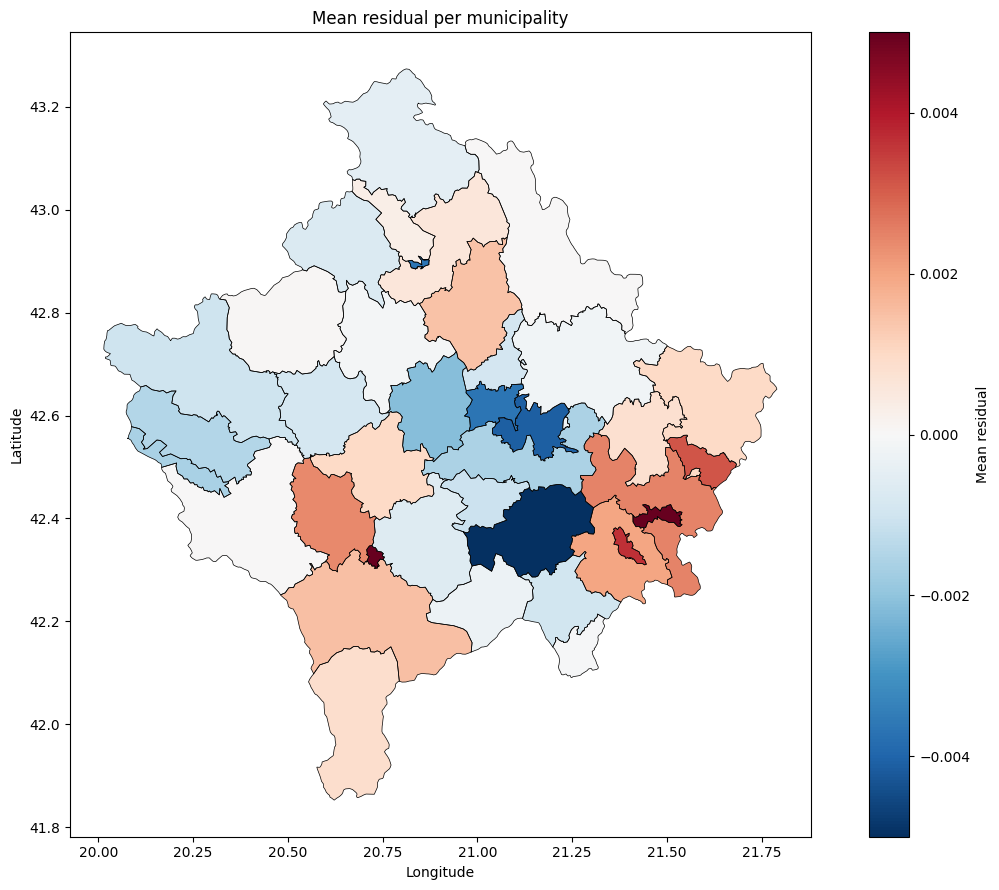

     municipality  mean_residual
          Partesh       0.008625
          Mamushe       0.006487
          Kllokot       0.003657
         Ranillug       0.003154
           Gjilan       0.002496
          Rahovec       0.002406
             Viti       0.001977
          Prizren       0.001503
         Vushtrri       0.001457
         Kamenice       0.000986
        Malisheve       0.000984
          Dragash       0.000898
        Novoberde       0.000812
Mitrovice e Jugut       0.000625
           Zveqan       0.000332
            Istog       0.000066
         Podujeve       0.000037
          Gjakove       0.000024
    Hani i Elezit      -0.000042
        Skenderaj      -0.000107
        Prishtine      -0.000168
          Shterpc      -0.000296
        Leposaviq      -0.000474
         Suhareke      -0.000640
      Zubin Potok      -0.000730
            Kline      -0.000873
           Obiliq      -0.000910
          Kacanik      -0.000971
             Peje      -0.001053
          

In [84]:
# Compute patch centroids in geographic coordinates
with rasterio.open('data/viirs_nightlights_kosovo_2025.tif') as src:
    tf = src.transform

centroids, resid_vals = [], []
idx = 0
for r in rows:
    for c in cols:
        lon, lat = rasterio.transform.xy(tf, r + PATCH // 2, c + PATCH // 2)
        centroids.append(Point(lon, lat))
        resid_vals.append(residuals[idx])
        idx += 1

patches_gdf = gpd.GeoDataFrame({'residual': resid_vals}, geometry=centroids, crs='EPSG:4326')

# Spatial join to municipalities
joined     = gpd.sjoin(patches_gdf, muni_clean[['municipality', 'geometry']], how='left', predicate='within')
muni_resid = joined.groupby('municipality')['residual'].mean().reset_index()
muni_resid.columns = ['municipality', 'mean_residual']
muni_plot  = muni_clean.merge(muni_resid, on='municipality', how='left')

# Choropleth
fig, ax = plt.subplots(figsize=(12, 9))
muni_plot.plot(column='mean_residual', cmap='RdBu_r', vmin=-0.005, vmax=0.005,
               legend=True, legend_kwds={'label': 'Mean residual'}, ax=ax)
muni_plot.boundary.plot(ax=ax, color='black', linewidth=0.5)
ax.set_title('Mean residual per municipality')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

print(muni_resid.sort_values('mean_residual', ascending=False).to_string(index=False))


### Census validation

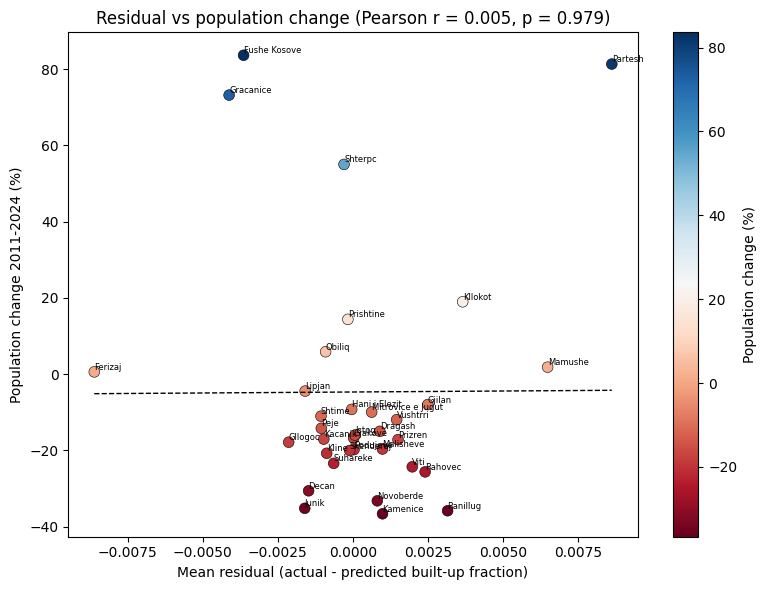

Municipalities in validation: 34
Pearson r = 0.0048, p-value = 0.9787


In [85]:
# Merge mean residual with census
validation = muni_resid.merge(df_census, on='municipality', how='inner')
validation = validation.dropna(subset=['pop_change_pct'])  # drop 4 northern municipalities

# Pearson r
from scipy import stats
r, pval = stats.pearsonr(validation['mean_residual'], validation['pop_change_pct'])

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(validation['mean_residual'], validation['pop_change_pct'],
                c=validation['pop_change_pct'], cmap='RdBu', s=60, edgecolors='black', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='Population change (%)')

for _, row in validation.iterrows():
    ax.annotate(row['municipality'], (row['mean_residual'], row['pop_change_pct']),
                fontsize=6, ha='left', va='bottom')

# Best fit line
m, b = np.polyfit(validation['mean_residual'], validation['pop_change_pct'], 1)
x_line = np.linspace(validation['mean_residual'].min(), validation['mean_residual'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1)

ax.set_xlabel('Mean residual (actual - predicted built-up fraction)')
ax.set_ylabel('Population change 2011-2024 (%)')
ax.set_title(f'Residual vs population change (Pearson r = {r:.3f}, p = {pval:.3f})')
plt.tight_layout()
plt.show()

print(f'Municipalities in validation: {len(validation)}')
print(f'Pearson r = {r:.4f}, p-value = {pval:.4f}')


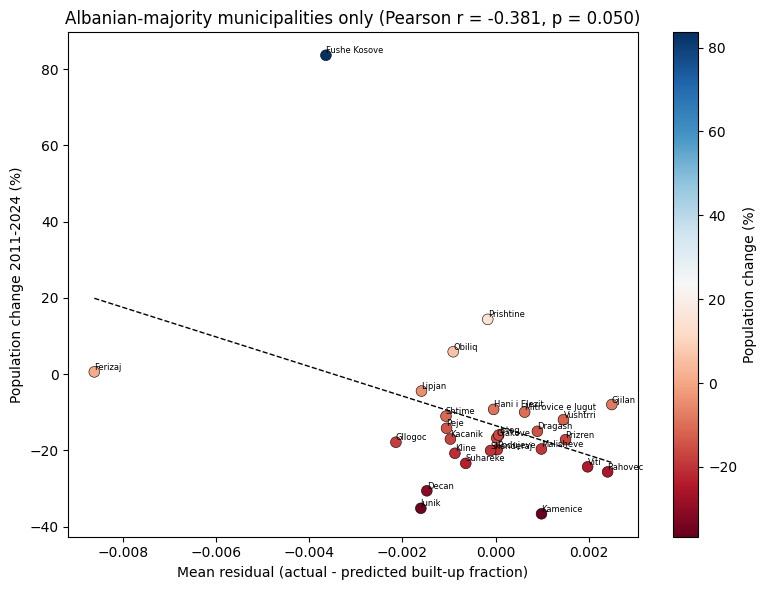

Municipalities: 27
Pearson r = -0.3809, p-value = 0.0500


In [86]:
# Restrict to Albanian-majority municipalities
serb_minority = ['Partesh', 'Gracanice', 'Kllokot', 'Mamushe', 'Ranillug', 'Shterpc', 'Novoberde']
validation_alb = validation[~validation['municipality'].isin(serb_minority)]

r_alb, pval_alb = stats.pearsonr(validation_alb['mean_residual'], validation_alb['pop_change_pct'])

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(validation_alb['mean_residual'], validation_alb['pop_change_pct'],
                c=validation_alb['pop_change_pct'], cmap='RdBu', s=60,
                edgecolors='black', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='Population change (%)')

for _, row in validation_alb.iterrows():
    ax.annotate(row['municipality'], (row['mean_residual'], row['pop_change_pct']),
                fontsize=6, ha='left', va='bottom')

m, b = np.polyfit(validation_alb['mean_residual'], validation_alb['pop_change_pct'], 1)
x_line = np.linspace(validation_alb['mean_residual'].min(), validation_alb['mean_residual'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1)

ax.set_xlabel('Mean residual (actual - predicted built-up fraction)')
ax.set_ylabel('Population change 2011-2024 (%)')
ax.set_title(f'Albanian-majority municipalities only (Pearson r = {r_alb:.3f}, p = {pval_alb:.3f})')
plt.tight_layout()
plt.show()

print(f'Municipalities: {len(validation_alb)}')
print(f'Pearson r = {r_alb:.4f}, p-value = {pval_alb:.4f}')
